# Figure 4 — Hair Follicle Aging: Cell Composition & Communication

## Load libraries

In [1]:
library(Seurat)
library(ggplot2)
library(ggpubr)
library(dplyr)
library(stringr)
library(grid)
library(tibble)
library(parallel)
library(RColorBrewer)
library(patchwork)
library(future)
library(ComplexHeatmap)
library(clusterProfiler)
library(viridis)
library(tidyr)
library(ggrepel)
library(Signac)
library(CellChat)
library(reshape2)
library(gridExtra)
library(pheatmap)

Attaching SeuratObject


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


ComplexHeatmap version 2.14.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))




clusterProfiler v4.6.0  For help: https://yulab-smu.top/biomedical-knowledg

## Setup: directories, colors, theme

In [26]:
DATA_DIR <- "data"
OUT_DIR  <- "output"
dir.create(OUT_DIR, showWarnings = FALSE)

# ---- Color & Theme ----
colorlist <- c("#FFFF00", "#1CE6FF", "#FF34FF", "#FF4A46", "#008941",
               "#006FA6", "#A30059", "#FFE4E1", "#0000A6", "#63FFAC",
               "#B79762", "#004D43", "#8FB0FF", "#997D87", "#5A0007",
               "#809693", "#1B4400", "#4FC601", "#3B5DFF", "#FF2F80",
               "#BA0900", "#6B7900", "#00C2A0", "#FFAA92", "#FF90C9",
               "#B903AA", "#DDEFFF", "#7B4F4B", "#A1C299", "#0AA6D8",
               "#00A087FF", "#4DBBD5FF", "#E64B35FF", "#3C5488FF", "#F38400",
               "#A1CAF1", "#C2B280", "#848482", "#E68FAC", "#0067A5",
               "#F99379", "#604E97", "#F6A600", "#B3446C", "#DCD300",
               "#882D17", "#8DB600", "#654522", "#E25822", "#2B3D26",
               "#191970", "#000080", "#6495ED", "#1E90FF", "#00BFFF",
               "#00FFFF", "#FF1493", "#FF00FF", "#A020F0", "#63B8FF",
               "#008B8B", "#54FF9F", "#00FF00", "#76EE00", "#FFF68F")

black_theme <- function() {
  theme(
    panel.grid = element_blank(),
    panel.background = element_rect(fill = NA),
    panel.border = element_rect(color = "white", linewidth = 0.5, fill = NA),
    plot.title = element_text(hjust = 0.5, size = 14, color = "white"),
    plot.background = element_rect(fill = 'black'),
    axis.line = element_line(color = "white", linewidth = 0),
    axis.text = element_text(color = "white", size = 12),
    axis.text.x = element_text(angle = 0, hjust = 0.5, vjust = 0.5),
    axis.title = element_text(color = "white", size = 14),
    axis.ticks = element_line(color = "white", linewidth = 0.5),
    legend.title = element_text(color = "white", size = 12),
    legend.text = element_text(color = "white", size = 12),
    legend.key = element_rect(fill = NA),
    legend.background = element_rect(fill = NA),
    legend.position = "right"
  )
}

## Load Seurat object & metadata

In [3]:
# ---- Load Seurat object ----
obj <- readRDS(file.path(DATA_DIR, "HF_RNA_postQC_rpca_241011.rds"))
meta <- readRDS(file.path(DATA_DIR, "HF_RNA_rpca_meta_240612.rds"))

meta$Age <- as.numeric(as.character(meta$Age))
meta$AgeGroup <- sapply(meta$Age, function(a) {
  if (is.na(a)) NA
  else if (3 <= a & a <= 17) "Juvenile"
  else if (18 <= a & a <= 39) "Prime age"
  else if (40 <= a & a <= 59) "Mid age"
  else "Old age"
})
meta$AgeGroup <- factor(meta$AgeGroup, levels = c("Juvenile", "Prime age", "Mid age", "Old age"), ordered = FALSE)
meta$sample <- ifelse(grepl("^H[BO]", meta$sample), "HO",
                     ifelse(meta$sample == "AB" | meta$sample == "AO", "AO", meta$sample))
meta$sample <- factor(meta$sample, levels = c('HO', 'AO', 'AF'))
obj@meta.data <- meta[colnames(obj),]

RCTD.color <- read.csv(file.path(DATA_DIR, "RCTD.color1_251210.csv"))
color1 <- RCTD.color$Color
names(color1) <- RCTD.color$abbreviation

RCTD.color2 <- read.delim(file.path(DATA_DIR, "RCTD.color_LastlEdition240612.txt"), header = TRUE, sep = "\t")
recoding <- setNames(RCTD.color2$abbreviation, RCTD.color2$order)

## Figure 4a — Spatial Plot

空间图由 Figure4a_spatial.py 生成。

## Figure 4b — Cell Proportion vs Age Correlation

散点回归图 (patchwork)：展示各细胞类型比例与年龄的相关性。

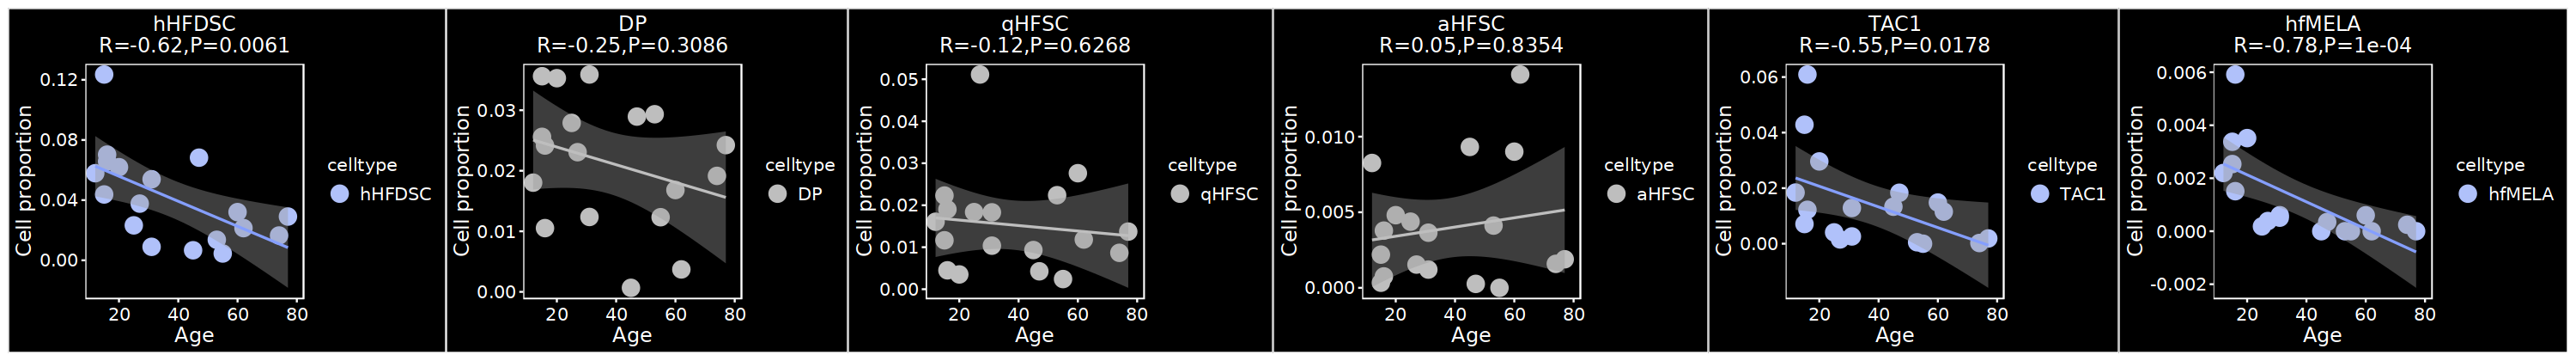

In [27]:
Cellratio_4b <- read.csv(file.path(DATA_DIR, "Figure4b_cellratio.csv"), row.names = 1)
Corr_4b <- read.csv(file.path(DATA_DIR, "Figure4b_corr.csv"), row.names = 1)

for (i in 1:nrow(Cellratio_4b)) {
  for (j in 1:nrow(Corr_4b)) {
    if (Cellratio_4b$celltype[i] == Corr_4b$celltype[j]) {
      Cellratio_4b$p_value[i] <- Corr_4b$p_value[j]
      Cellratio_4b$corr[i] <- Corr_4b$corr[j]
      Cellratio_4b$order[i] <- Corr_4b$order[j]
      break
    }
  }
}

set_colors <- function(corr, p) {
  if (corr > 0.4 && p < 0.05) return(c("#F79B3F", "#f3c81d"))
  else if (corr < -0.4 && p < 0.05) return(c("#859FFF", "#B0C1FA"))
  else return(c("grey", "grey"))
}

for (i in 1:nrow(Cellratio_4b)) {
  colors <- set_colors(Cellratio_4b$corr[i], Cellratio_4b$p_value[i])
  Cellratio_4b$cols1[i] <- colors[1]
  Cellratio_4b$cols2[i] <- colors[2]
}
Cellratio_4b <- Cellratio_4b[order(Cellratio_4b$order), ]

Cellratio_4b$celltype <- recode(Cellratio_4b$celltype, !!!recoding)
Cellratio_4b$celltype[Cellratio_4b$celltype == "Unknown"] <- 'SW'
Cellratio_4b$celltype[Cellratio_4b$celltype == 'MELASC'] <- 'hfMELA'

Allcelltype_4b <- c('hHFDSC', 'DP', 'qHFSC', 'aHFSC', 'TAC1', 'hfMELA')
plot.list_4b <- lapply(Allcelltype_4b, function(x) {
  Cellratio_4b$Age <- as.integer(as.character(Cellratio_4b$Age))
  sub <- subset(Cellratio_4b, celltype == x)
  corr <- round(unique(sub$corr), 2)
  p_value <- round(unique(sub$p_value), 4)
  cols1 <- unique(sub$cols1)
  cols2 <- unique(sub$cols2)

  ggplot(sub, aes(x = Age, y = Freq)) +
    geom_point(size = 5, aes(color = celltype)) +
    scale_color_manual(values = cols2) +
    geom_smooth(method = "lm", formula = 'y ~ x', se = TRUE, color = cols1, size = 0.7) +
    scale_fill_manual(values = cols2) +
    labs(x = "Age", y = "Cell proportion") +
    ggtitle(paste0(x, "\nR=", corr, ",P=", p_value)) +
    coord_cartesian(xlim = c(min(sub$Age), max(sub$Age) + 2)) +
    black_theme()
})

p_4b <- wrap_plots(plot.list_4b, nrow = 1)
ggsave(p_4b, file = file.path(OUT_DIR, "Figure4b_cell_proportion_age_correlation.pdf"), width = 25, height = 3.5)
options(repr.plot.width =25, repr.plot.height = 3.5)
p_4b

## Figure 4c — Bulk DEG Number Barplot (Old vs Young)

双向堆叠柱状图：展示各细胞类型在 Old vs Young 中的 DEG 数量。

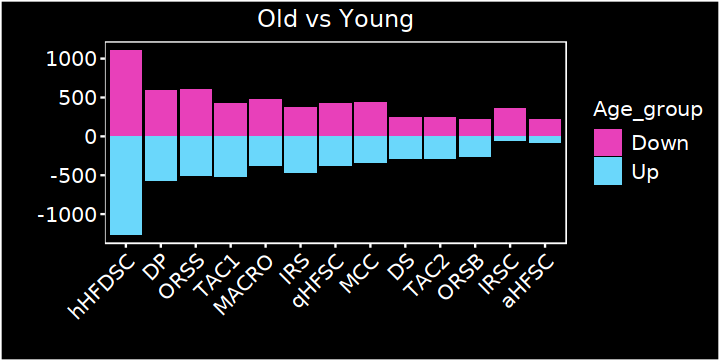

In [28]:
merged_4c <- read.csv(file.path(DATA_DIR, "Figure4c_bulk_marker.csv"), row.names = 1)
colnames(merged_4c)[colnames(merged_4c) == "X"] <- "gene"
colnames(merged_4c)[colnames(merged_4c) == "celltype"] <- "cluster"
merged_4c <- subset(merged_4c, pvalue < 0.05)

target_clusters_4c <- c("Dermal_papilla", "Dermal_sheath", "hfDSC", 'Macrophage',
                         "Active_HFSC", "HF_IRS", "IRS_cuticle",
                         "Medulla_Cortex_Cuticle", "ORS_basal", "ORS_Suprabasal",
                         "Quiescent_HFSC", "TAC_1", "TAC_2")
merged_4c <- merged_4c[merged_4c$cluster %in% target_clusters_4c, ]

result_4c <- data.frame()
for (ct in unique(merged_4c$cluster)) {
  sub <- subset(merged_4c, cluster == ct)
  result_4c <- rbind(result_4c, data.frame(
    celltype = ct,
    young = sum(sub$log2FoldChange > 0.5),
    old = sum(sub$log2FoldChange < -0.5)
  ))
}

newdf_4c <- melt(result_4c, id.vars = "celltype", variable.name = "Age_group", value.name = "Count")
newdf_4c$Count2 <- newdf_4c$Count
newdf_4c$Count2[newdf_4c$Age_group == "old"] <- -newdf_4c$Count2[newdf_4c$Age_group == "old"]
newdf_4c$celltype <- recode(newdf_4c$celltype, !!!recoding)

sum_count_4c <- aggregate(Count ~ celltype, data = newdf_4c, FUN = sum)
sum_count_4c <- sum_count_4c[order(sum_count_4c$Count, decreasing = TRUE), ]
sub_count_4c <- tail(sum_count_4c, 20)
plotdf_4c <- subset(newdf_4c, celltype %in% sub_count_4c$celltype)
plotdf_4c$celltype <- factor(plotdf_4c$celltype, levels = sub_count_4c$celltype)

p_4c <- ggplot(plotdf_4c, aes(x = celltype, y = Count2, fill = Age_group)) +
  geom_bar(stat = "identity", position = "stack") +
  scale_fill_manual(values = c("old" = '#6ad7fb', "young" = '#e840ba'),
                    labels = c("old" = "Up", "young" = "Down")) +
  black_theme() + theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1))+
  labs(x = "", y = "", title = "Old vs Young")

ggsave(p_4c, file = file.path(OUT_DIR, "Figure4c_DEG_number_barplot.pdf"), width = 6, height = 3)
options(repr.plot.width =6, repr.plot.height = 3)
p_4c

## Figure 4d — hHFDSC Aging GO Heatmap

pheatmap 热图：展示 hHFDSC 衰老相关 GO 通路的上调/下调。

png 
  2

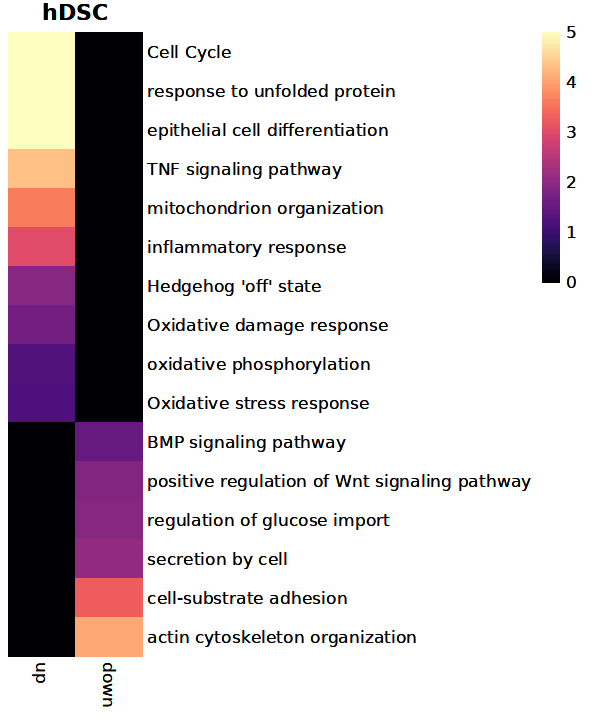

In [34]:
data_4d <- read.csv(file.path(DATA_DIR, "Figure4d_go.csv"))
data_4d$group <- ifelse(data_4d$X_LogP_hfDSC_Aging_up != 0, "up",
                        ifelse(data_4d$X_LogP_hfDSC_Aging_down != 0, "down", "none"))
data_4d$logP <- data_4d$X_LogP_hfDSC_Aging_up
data_4d[data_4d$group == 'down', ]$logP <- data_4d[data_4d$group == 'down', ]$X_LogP_hfDSC_Aging_down
data_4d$P <- exp(data_4d$logP)
data_4d$negLog10P <- -log10(data_4d$P)

matrix_4d <- data_4d %>%
  select(group, negLog10P, Description) %>%
  spread(key = group, value = negLog10P) %>%
  tibble::column_to_rownames(var = "Description")
matrix_4d[is.na(matrix_4d)] <- 0
matrix_4d <- matrix_4d[order(matrix_4d[, "up"] == 0, matrix_4d[, "down"],
                              matrix_4d[, "down"] == 0, -matrix_4d[, "up"]), ]
matrix_4d <- matrix_4d[, c("up", "down")]
matrix_4d[matrix_4d > 5] <- 5
matrix_4d <- as.matrix(matrix_4d)

p_4d <- pheatmap(matrix_4d,
                 scale = "none",
                 color = viridis(100, option = "A"),
                 border_color = NA,
                 cluster_rows = FALSE,
                 cluster_cols = FALSE,
                 main = "hDSC")

pdf(file.path(OUT_DIR, "Figure4d_hHFDSC_aging_GO_heatmap.pdf"), width = 5, height = 6)
p_4d
dev.off()
options(repr.plot.width =5, repr.plot.height = 6)
p_4d

## Figure 4e — hHFDSC DotPlot by AgeGroup

DotPlot：展示 hHFDSC 在不同年龄组中的 marker 基因表达。

Warning message:
“Scaling data with a low number of groups may produce misleading results”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


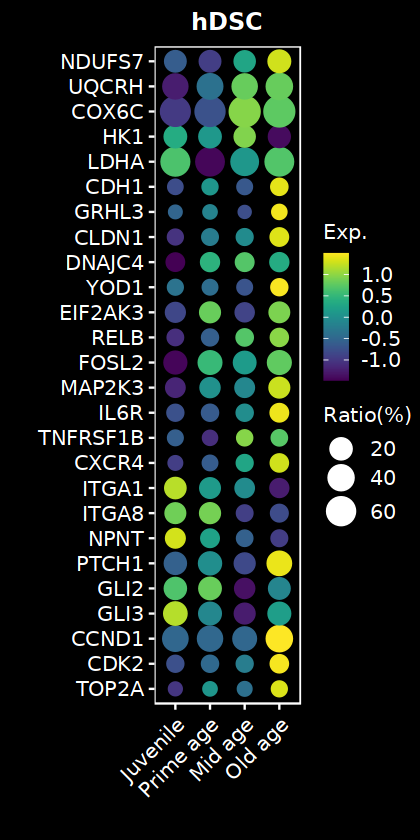

In [37]:
sub_4e <- subset(obj, sample_type == "HB" & Abbreviation == 'hHFDSC')

gene_4e <- c("NDUFS7", "UQCRH", "COX6C", "HK1", "LDHA", "CDH1", "GRHL3", "CLDN1",
             "DNAJC4", "YOD1", "EIF2AK3", "RELB", "FOSL2", "MAP2K3",
             "IL6R", "TNFRSF1B", "CXCR4", "ITGA1", "ITGA8", "NPNT",
             "PTCH1", "GLI2", "GLI3", "CCND1", "CDK2", "TOP2A")

DefaultAssay(sub_4e) <- 'RNA'
p_4e <- DotPlot(sub_4e, assay = "RNA", features = rev(gene_4e), group.by = "AgeGroup") +
  black_theme() + coord_flip() +
  scale_color_viridis(option = "viridis") +
  scale_size_continuous(guide = guide_legend(order = 1), range = c(3, 8)) +
  guides(size = guide_legend(title = "Ratio(%)", override.aes = list(color = "white")),
         color = guide_colorbar(title = "Exp.")) +
  labs(x = "", y = "", title = "hDSC")+ theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1))

ggsave(p_4e, file = file.path(OUT_DIR, "Figure4e_hHFDSC_DotPlot.pdf"), width = 3.5, height = 7)
options(repr.plot.width =3.5, repr.plot.height = 7)
p_4e

## Figure 4g — SASP / Tao W et al. Score Boxplot

Boxplot+误差棒 (patchwork)：展示 hHFDSC 中 SASP 和 Tao W et al. 基因模块评分随年龄变化。

In [75]:
data_4g <- subset(obj@meta.data, Abbreviation %in% c('hHFDSC') & sample_type == 'HB')
unique(data_4g$sample_type)

[1] "HB"

`summarise()` has grouped output by 'AgeGroup', 'batch1'. You can override
using the `.groups` argument.


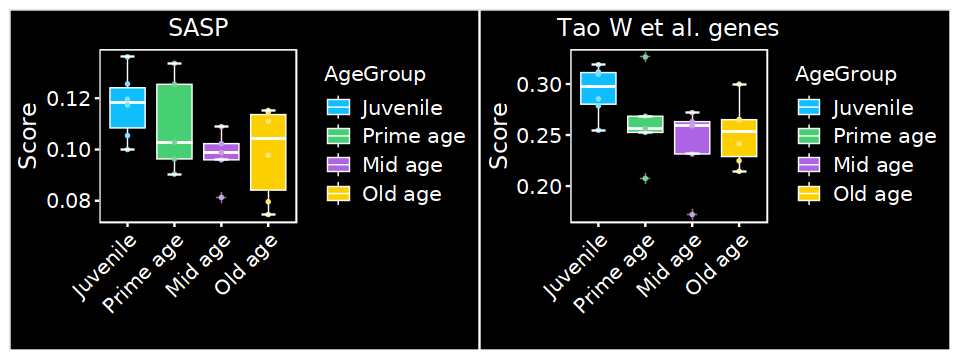

In [76]:
obj_module_4g <- readRDS(file.path(DATA_DIR, "Figure4g_gene_module.rds"))
obj$SASP_Features1 <- obj_module_4g[colnames(obj), ]$SASP_Features1
obj$Han_mmc5_Features1 <- obj_module_4g[colnames(obj), ]$Han_mmc5_Features1
colnames(obj@meta.data)[colnames(obj@meta.data) == 'SASP_Features1'] <- 'SASP'
colnames(obj@meta.data)[colnames(obj@meta.data) == 'Han_mmc5_Features1'] <- 'Tao W et al. genes'

data_4g <- subset(obj@meta.data, Abbreviation %in% c('hHFDSC') & sample_type == 'HB')
data_4g <- data_4g[, c("batch1", "AgeGroup", "SASP", "Tao W et al. genes")]
data_4g <- gather(data_4g, key = "group", value = "value", SASP, `Tao W et al. genes`)
grouped_4g <- group_by(data_4g, AgeGroup, batch1, group)
data_4g <- summarise(grouped_4g, avg_value = mean(value))

colorlist1 <- c("#0ebeff", "#47cf73", "#ae63e4", "#fcd000", "#ff3c41")
colorlist2 <- c("#85deff", "#80cf9a", "#c7a0e4", "#fce576", "#ff878a")

plot.list_4g <- lapply(sort(unique(data_4g$group)), function(ct) {
  df <- data_4g[data_4g$group == ct, ]
  p1 <- ggplot(df, aes(x = AgeGroup, y = avg_value), fill = AgeGroup) +
    geom_boxplot(aes(fill = AgeGroup), outlier.shape = 3, outlier.colour = "white",
                 outlier.alpha = 0.5, color = "white", linewidth = 0.3) +
    geom_point(aes(color = AgeGroup), size = 0.5) +
    scale_color_manual(values = colorlist2) +
    scale_fill_manual(values = colorlist1) +
    scale_x_discrete(limits = levels(data_4g$AgeGroup)) +
    black_theme() + labs(x = "", y = "Score", title = ct) +
    guides(color = guide_colorbar(title = ""))+ 
    theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1))

  errorbar.df <- ggplot_build(p1)$data[[1]] %>% select(x, ymin, ymax)
  p1 +
    geom_segment(data = errorbar.df, aes(x = x - 0.15, xend = x + 0.15, y = ymin, yend = ymin), color = "white") +
    geom_segment(data = errorbar.df, aes(x = x - 0.15, xend = x + 0.15, y = ymax, yend = ymax), color = "white")
})

p_4g <- wrap_plots(plot.list_4g, nrow = 1)
ggsave(p_4g, file = file.path(OUT_DIR, "Figure4g_SASP_boxplot.pdf"), width = 8, height = 3)
options(repr.plot.width =8, repr.plot.height = 3)
p_4g

## Figure 4k — CellChat Age Source Barplot

柱状图：展示 Young vs Old 各细胞类型作为 source 的通讯概率。

数据准备见 `Figure4k_cellchat_prepare.ipynb`。

`summarise()` has grouped output by 'type'. You can override using the
`.groups` argument.
Adding missing grouping variables: `type`


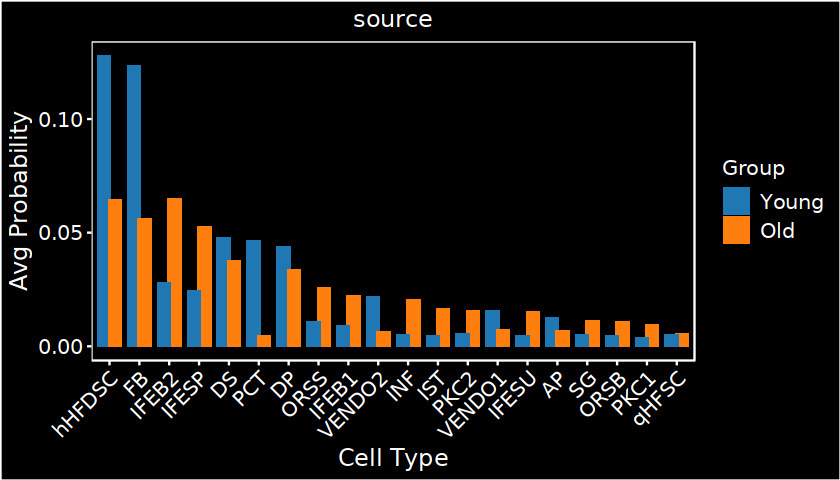

In [55]:
nep_4k <- read.csv(file.path(DATA_DIR, "Figure4k_cellchat_nep.csv"), row.names = 1)
data.nep_4k <- nep_4k %>%
  select(source, target, prob, age_group)
data.nep_4k <- gather(data.nep_4k, key = "type", value = "celltype", source, target)
data.nep_4k$type <- paste(data.nep_4k$age_group, data.nep_4k$type)
data.nep_4k <- data.nep_4k %>%
  group_by(type, celltype) %>%
  summarise(avg_prob = sum(prob))

data.nep_4k$celltype[data.nep_4k$celltype == "Unknown"] <- "Schwann"
data.nep_4k$celltype <- recode(data.nep_4k$celltype, !!!recoding)

data.sub_4k <- subset(data.nep_4k, type %in% c("Old source", "Young source"))
data.count_4k <- data.sub_4k %>%
  select(celltype, avg_prob) %>%
  group_by(celltype) %>%
  arrange(avg_prob)
data.nep_4k <- subset(data.nep_4k, celltype %in% tail(unique(data.count_4k$celltype), 20))

source_4k <- subset(data.nep_4k, grepl("source", type))
source_4k <- source_4k %>%
  separate(type, into = c("group", "type"), sep = " ") %>%
  arrange(desc(avg_prob))

celltype_order_4k <- source_4k %>% pull(celltype) %>% unique()
source_4k$celltype <- factor(source_4k$celltype, levels = celltype_order_4k)
source_4k$group <- factor(source_4k$group, levels = c("Young", "Old"))

p_4k <- ggplot(source_4k, aes(x = celltype, y = avg_prob, fill = group)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.7)) +
  scale_fill_manual(values = c("Young" = "#1f77b4", "Old" = "#ff7f0e")) +
  labs(x = "Cell Type", y = "Avg Probability", fill = "Group") +
  black_theme() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1)) +
  ggtitle("source")

ggsave(p_4k, file = file.path(OUT_DIR, "Figure4k_cellchat_source_barplot.pdf"), width = 7, height = 4)
options(repr.plot.width = 7, repr.plot.height = 4)
p_4k

## Figure 4l — CellChat Aging Pathway RankNet

CellChat rankNet：比较 Young vs Old 的信号通路通讯概率。

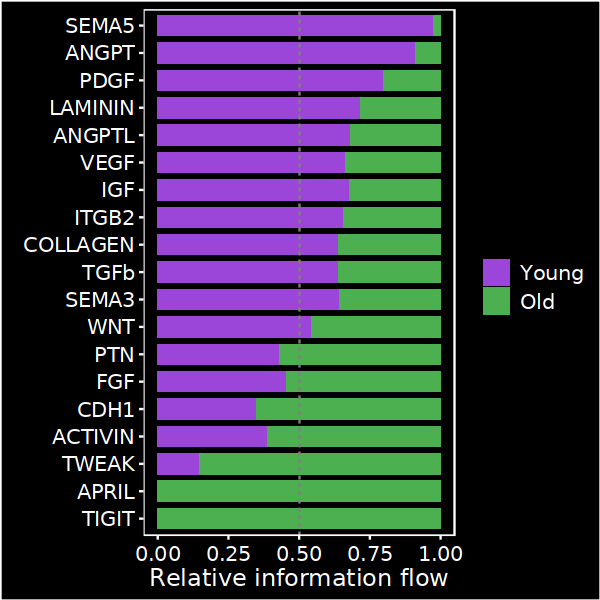

In [64]:
cellchat_4l <- readRDS(file.path(DATA_DIR, "Figure4l_cellchat.rds"))

pathway_4l <- c("TIGIT", "APRIL", "TWEAK", "CDH1", "ACTIVIN",
                "FGF", "WNT", "COLLAGEN", "ANGPTL", "VEGF",
                "TGFb", "IGF", "ITGB2", "LAMININ", "PDGF",
                "ANGPT", "SEMA5", "SEMA3", "PTN")
colors_4l <- c("#9b45d9", "#4CAF50")

p_4l <- rankNet(cellchat_4l, mode = "comparison", signaling = pathway_4l,
                comparison = c(1, 2), stacked = T, do.stat = TRUE, color.use = colors_4l) +
  black_theme()+
  theme(
    axis.text.y = element_text(size = 12, color = "white"),
    axis.text.x = element_text(size = 12, color = "white"),
    axis.title = element_text(size = 14, color = "white"),
    plot.title = element_text(hjust = 0.5, size = 14, color = "white"),
    panel.grid = element_blank(),
    legend.position = "right"
  )

ggsave(p_4l, file = file.path(OUT_DIR, "Figure4l_cellchat_pathway_barplot.pdf"), width = 5, height = 5)
options(repr.plot.width = 5, repr.plot.height = 5)
p_4l

## Figure 4m — hHFDSC/aHFSC Ligand & Receptor DotPlot

两组 DotPlot：分别展示 hHFDSC 的配体和 aHFSC 的受体表达。

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


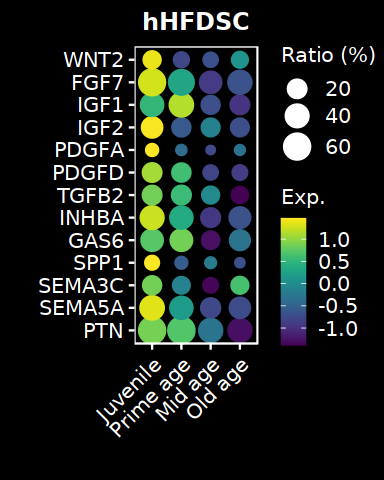

In [81]:
DefaultAssay(obj) <- 'RNA'
sub_4m_hHFDSC <- subset(obj, Abbreviation %in% c('hHFDSC') & sample_type == 'HB')
sub_4m_aHFSC <- subset(obj, Abbreviation %in% c('aHFSC') & sample_type == 'HB')

gene_ligand_4m <- rev(c("WNT2", "FGF7", "IGF1", "IGF2", "PDGFA", "PDGFD",
                         "TGFB2", "INHBA", "GAS6", "SPP1", "SEMA3C", "SEMA5A", "PTN"))
gene_receptor_4m <- rev(c("LRP5", "LRP6", "LGR5", "FGFR2", "IGF1R", "PDGFRA", "PDGFRB",
                           "TGFBR2", "ACVR1B", "ACVR2A", "AXL", "CD44", "NRP1", "NRP2", "PTPRZ1"))

p_4m_hHFDSC <- DotPlot(sub_4m_hHFDSC, features = gene_ligand_4m, group.by = 'AgeGroup') +
  coord_flip() +
  scale_color_viridis(option = "viridis") +
  scale_size_continuous(guide = guide_legend(order = 1), range = c(2, 7)) +
  guides(size = guide_legend(title = "Ratio (%)", override.aes = list(color = "white")),
         color = guide_colorbar(title = "Exp.")) +
  black_theme() + labs(x = "", y = "", title = "hHFDSC") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1))

ggsave(p_4m_hHFDSC, file = file.path(OUT_DIR, "Figure4m_hHFDSC_ligand_DotPlot.pdf"), width = 3.2, height = 4)
options(repr.plot.width = 3.2, repr.plot.height = 4)
p_4m_hHFDSC

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


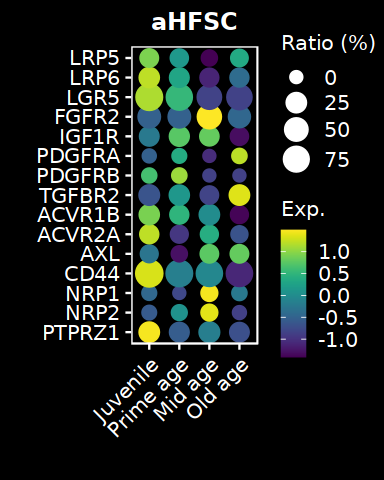

In [82]:
DefaultAssay(sub_4m_aHFSC) <- 'RNA'
p_4m_aHFSC <- DotPlot(sub_4m_aHFSC, features = gene_receptor_4m, group.by = 'AgeGroup') +
  coord_flip() +
  scale_color_viridis(option = "viridis") +
  scale_size_continuous(guide = guide_legend(order = 1), range = c(3, 7)) +
  guides(size = guide_legend(title = "Ratio (%)", override.aes = list(color = "white")),
         color = guide_colorbar(title = "Exp.")) +
  black_theme() + labs(x = "", y = "", title = "aHFSC") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1))

ggsave(p_4m_aHFSC, file = file.path(OUT_DIR, "Figure4m_aHFSC_receptor_DotPlot.pdf"), width = 3.2, height = 4)
options(repr.plot.width = 3.2, repr.plot.height = 4)
p_4m_aHFSC

## Figure 4n — MACRO/hDSC IL1 DotPlot (AGA)

两组 DotPlot：展示 MACRO 的 IL1/TNF 配体和 hDSC 的受体表达。

In [98]:
unique(sub_4n_hDSC$Abbreviation)
unique(sub_4n_hDSC$sample_type)

[1] "hHFDSC"

[1] "HB"

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


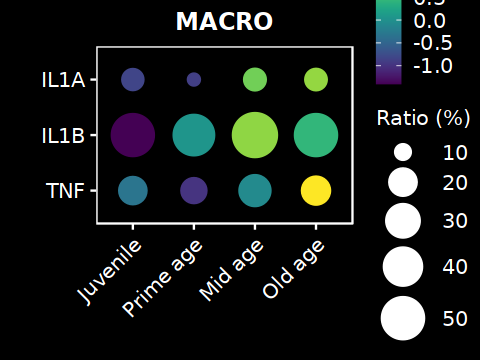

In [102]:
sub_4n_MACRO <- subset(obj, Abbreviation %in% c('MACRO') & sample_type == 'HB')
sub_4n_hDSC <- subset(obj, Abbreviation %in% c('hHFDSC') & sample_type == 'HB')

gene_MACRO_4n <- rev(c("IL1A", "IL1B", "TNF"))
gene_hDSC_4n <- rev(c("IL1R1", "TNFRSF1A"))

DefaultAssay(sub_4n_MACRO) <- 'RNA'
p_4n_MACRO <- DotPlot(sub_4n_MACRO, features = gene_MACRO_4n, group.by = 'AgeGroup') +
  coord_flip() +
  scale_color_viridis(option = "D", direction = 1) +
  scale_size_continuous(guide = guide_legend(order = 1), range = c(3, 12)) +
  guides(size = guide_legend(title = "Ratio (%)", override.aes = list(color = "white")),
         color = guide_colorbar(title = "Exp.")) +
  black_theme() + labs(x = "", y = "", title = "MACRO") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1))

ggsave(p_4n_MACRO, file = file.path(OUT_DIR, "Figure4n_IL1_MACRO_DotPlot.pdf"), width = 4, height = 3)
options(repr.plot.width = 4, repr.plot.height = 3)
p_4n_MACRO

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


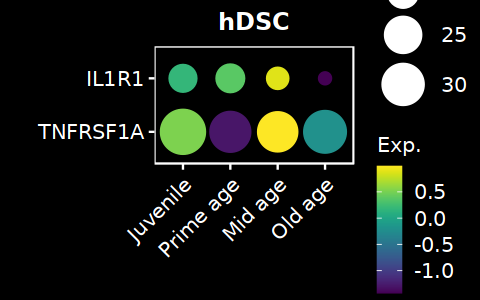

In [105]:
DefaultAssay(sub_4n_hDSC) <- 'RNA'
p_4n_hDSC <- DotPlot(sub_4n_hDSC, features = gene_hDSC_4n, group.by = 'AgeGroup') +
  coord_flip() +
  scale_color_viridis(option = "D", direction = 1) +
  scale_size_continuous(guide = guide_legend(order = 1), range = c(3, 12)) +
  guides(size = guide_legend(title = "Ratio (%)", override.aes = list(color = "white")),
         color = guide_colorbar(title = "Exp.")) +
  black_theme() + labs(x = "", y = "", title = "hDSC") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1))

ggsave(p_4n_hDSC, file = file.path(OUT_DIR, "Figure4n_IL1R1_hDSC_DotPlot.pdf"), width = 4, height = 2.5)
options(repr.plot.width = 4, repr.plot.height = 2.5)
p_4n_hDSC